### Define Plot Style for Thesis

In [82]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import numpy as np
import pandas as pd



def plot_thesis_setup(x_size = 8, y_size = 4, alternative_colours = False, colour_choice = 1, dotted_lines = True):
    plt.figure(figsize=(x_size, y_size))
    plt.style.use('ggplot')  # or 'ggplot', 'bmh', 'classic'
    
    # Override the default color cycle with distinct colors
    if alternative_colours:
        if colour_choice == 1:
            plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
                "#be0000",  # blue
                "#ff045c",  # orange
                "#515151",  # green
                "#eea701",  # red
                "#00AA11",  # purple
                "#000000",  # brown
                "#2210c6",  # pink
                "#FB4BCC",  # gray
                "#1E42B9",  # olive
                "#599500"   # cyan
            ])

        else:
            plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
                "#0026ff",  # blue
                "#397eff",  # orange
                "#529DFF",  # green
                "#55b2ce",  # red
                "#8C7FBD",  # purple
                "#646464",  # brown
                "#474747",  # pink
                "#000000",  # gray
                "#1F0857",  # olive
                "#0D076D"   # cyan
            ])
    
    if dotted_lines:
        plt.rcParams['axes.prop_cycle'] = plt.cycler(linestyle = [
            (0, (1, 0)), 
            (0, (1, 0)), 
            (0, (1, 0)), 
            (0, (5, 5)), 
            (0, (5, 5)), 
            (0, (5, 5)), 
            (0, (1, 1)), 
            (0, (1, 1)),
            (0, (1, 1)),
            (0, (4, 5, 1, 2)),
            (0, (4, 5, 1, 2)),
            (0, (4, 5, 1, 2)),
            (0, (1, 0))
            ],
            color=[
                "#000000",  
                "#970000",  
                "#534AFF", 
                "#000000",  
                "#970000",  
                "#534AFF", 
                "#000000",  
                "#970000",  
                "#534AFF",  
                "#000000",  
                "#970000",  
                "#534AFF", 
                "#2BFF00",
            ])


def plot_thesis_format(title, xlabel, ylabel, legend = True, grid = True, save = False, filename = "default"):
    plt.title(title, fontsize = 15)
    if legend:
        plt.legend(fontsize = 10)    
    if not grid:
        plt.grid()
    plt.xlabel(xlabel, fontsize = 14)
    plt.xticks(fontsize = 11)
    plt.ylabel(ylabel, fontsize = 14)
    plt.yticks(fontsize = 11)
    if save:
        plt.savefig("Figures/" + filename + ".pdf", bbox_inches = 'tight')


### Generate Plot for Stocks Over Time

In [83]:
df = pd.read_excel("Archegos.xlsx", sheet_name = "Data")
df["Date"] = pd.to_datetime(df["Date"], format = "%d/%m/%Y")
df = df.set_index("Date")
df = df.sort_index()

<Figure size 800x400 with 0 Axes>

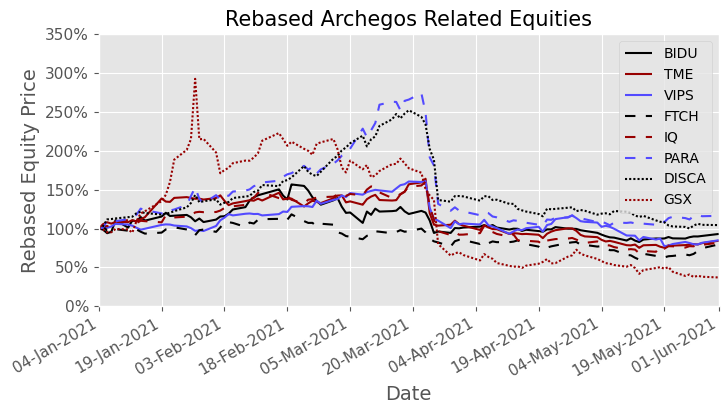

In [84]:
plot_thesis_setup(x_size=8, y_size= 4, alternative_colours = False)
stocks = ["BIDU", "TME", "VIPS", "FTCH", "IQ", "PARA", "DISCA", "GSX"]
ax = (df[stocks].loc["2021-01-01":"2021-06-01"]/df[stocks].loc["2021-01-04"]*100).plot(figsize=(8, 4), fontsize= 11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))

start_tick = datetime.datetime(2021, 1, 4)
end_tick = datetime.datetime(2021, 6, 1)
ticks = [start_tick + datetime.timedelta(days=15 * i) for i in range((end_tick - start_tick).days // 15 + 1)]
ticks.append(end_tick)
ax.set_xticks(ticks)
ax.set_xlim(start_tick, end_tick)
y_ticks = ax.get_yticks()
plt.yticks(y_ticks, [str(int(tick)) + "%" for tick in y_ticks], fontsize = 12)

plot_thesis_format("Rebased Archegos Related Equities", "Date", "Rebased Equity Price", save = True, filename = "RebasedArchegosRelatedEquities")
plt.show()

<Figure size 800x400 with 0 Axes>

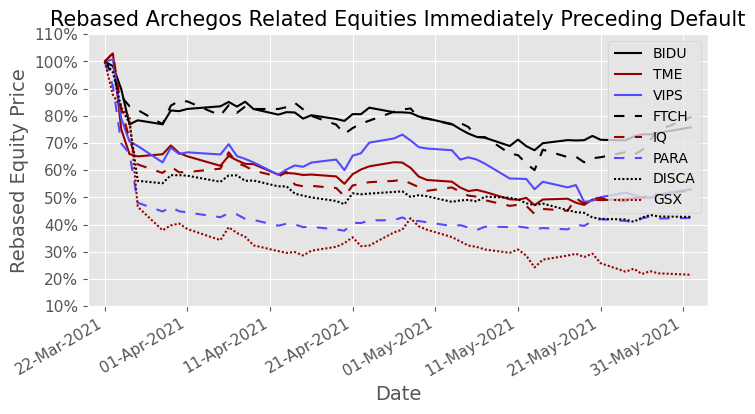

In [85]:
plot_thesis_setup(x_size=8, y_size= 4, alternative_colours = False)
stocks = ["BIDU", "TME", "VIPS", "FTCH", "IQ", "PARA", "DISCA", "GSX"]
ax = (df[stocks].loc["2021-03-22":"2021-06-01"]/df[stocks].loc["2021-03-22"]*100).plot(figsize=(8, 4), fontsize= 11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))

start_tick = datetime.datetime(2021, 3, 22)
end_tick = datetime.datetime(2021, 6, 1)
ticks = [start_tick + datetime.timedelta(days=10 * i) for i in range((end_tick - start_tick).days // 10 + 1)]
#ticks.append(end_tick)
ax.set_xticks(ticks)
ax.set_xlim(datetime.datetime(2021, 3, 20), datetime.datetime(2021, 6, 3))
y_ticks = ax.get_yticks()
plt.yticks(y_ticks, [str(int(tick)) + "%" for tick in y_ticks], fontsize = 12)

plot_thesis_format("Rebased Archegos Related Equities Immediately Preceding Default", "Date", "Rebased Equity Price", save = True, filename = "RebasedArchegosRelatedEquitiesPrecedingDefault")
plt.show()

### Generate Impact Related Plots

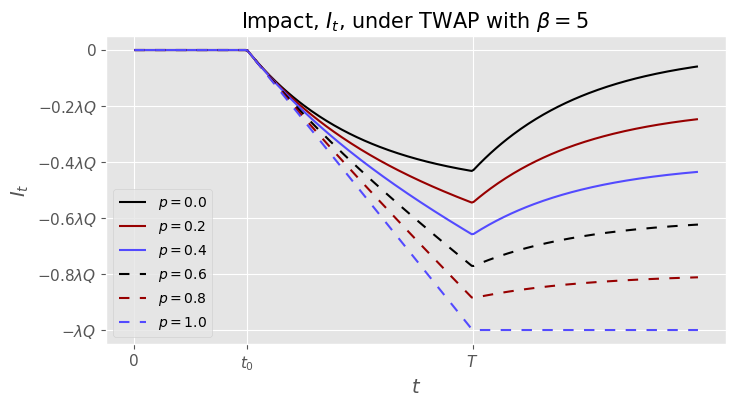

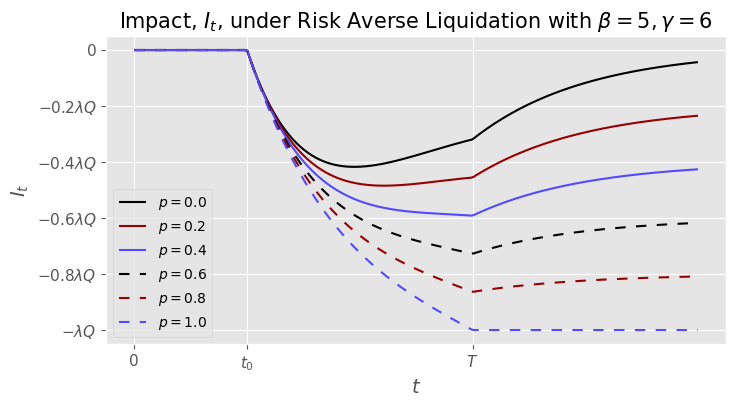

In [86]:
import ImpactFunctions

maturity = 1

steps = 300

times = np.linspace(0, maturity, steps)

plot_thesis_setup(alternative_colours = False)

for p in np.linspace(0, 1, 6):
    impact = ImpactFunctions.ImpactProcess(1, 5, permanent_proportion=p)

    process_1 = ImpactFunctions.TradingProcess(1, 0.2, 0.6, 0, times)

    plt.plot(times, impact.compute_impact(process_1), label = "$p = $" + str(int(p*10)/10))


plt.xticks([0, 0.2, 0.6], [0, r"$t_0$", r"$T$"], fontsize = 12)
plt.yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0], [r"$-\lambda Q$", r"$-0.8 \lambda Q$", r"$-0.6 \lambda Q$", r"$-0.4 \lambda Q$", r"$-0.2 \lambda Q$", 0], fontsize = 12)


plot_thesis_format(r"Impact, $I_t$, under TWAP with $\beta = 5$ ", "$t$", "$I_t$", save = True, filename = "TWAPImpactPlots")
plt.show()


maturity = 1

steps = 300

times = np.linspace(0, maturity, steps)

plot_thesis_setup(alternative_colours = False)

for p in np.linspace(0, 1, 6):
    impact = ImpactFunctions.ImpactProcess(1, 5, permanent_proportion=p)

    process_1 = ImpactFunctions.TradingProcess(1, 0.2, 0.6, 6, times)

    plt.plot(times, impact.compute_impact(process_1), label = "$p = $" + str(int(p*10)/10))


plt.xticks([0, 0.2, 0.6], [0, r"$t_0$", r"$T$"], fontsize = 12)
plt.yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0], [r"$-\lambda Q$", r"$-0.8 \lambda Q$", r"$-0.6 \lambda Q$", r"$-0.4 \lambda Q$", r"$-0.2 \lambda Q$", 0], fontsize = 12)


plot_thesis_format(r"Impact, $I_t$, under Risk Averse Liquidation with $\beta = 5, \gamma = 6$ ", "$t$", "$I_t$", save = True, filename = "RiskAverseImpactPlots")
plt.show()

### Plots for Basic Simulation

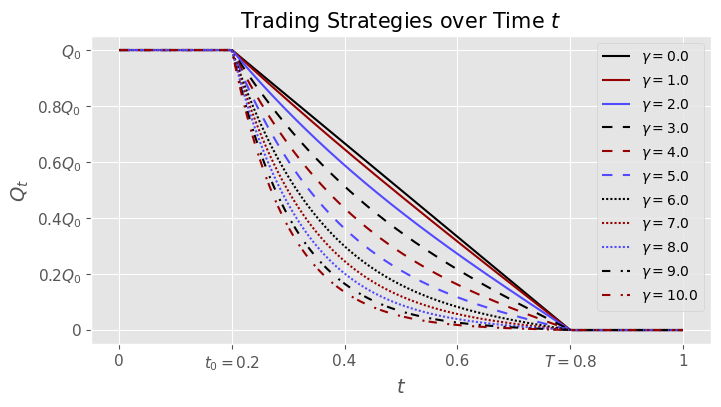

In [87]:
import StocksAndAgents

gammas = np.linspace(0, 10, 11)
times = np.linspace(0, 1, 300)

basic_agent = StocksAndAgents.Agent({str(gamma): ImpactFunctions.TradingProcess(1, 0.2, 0.8, gamma, times) for gamma in gammas}, "Basic")

plot_thesis_setup(alternative_colours = False)

for gamma in gammas:
    volume = basic_agent.trading_processes[str(gamma)].volume

    plt.plot(times, volume, label = r"$\gamma = $" + str(np.round(gamma,1)))


plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], [0, r"$t_0 = 0.2 $", 0.4, 0.6, r"$T = 0.8$", 1], fontsize = 12)
plt.yticks([1.0, 0.8, 0.6, 0.4, 0.2, 0], [r"$Q_0$", r"$0.8 Q_0$", r"$0.6  Q_0$", r"$0.4  Q_0$", r"$0.2 Q_0$", 0], fontsize = 12)


plot_thesis_format(r"Trading Strategies over Time $t$", "$t$", "$Q_t$", save = True, filename = "TradingStrategies")
plt.show()



In [88]:
# Setup of simulation

import pandas as pd

simulated_model = True

if simulated_model:

    start = 0
    end = 40
    steps = 300

    agent_names = ["Credit Suisse", "Deutsche Bank", "Goldman Sachs", "Morgan Stanley", "Nomura", "UBS"]
    start_times = np.array([4, 2, 2, 1, 3, 3])
    end_times = np.array([30, 10, 3, 3, 35, 10])
    times = np.linspace(start, end, steps)
    risk_aversions = np.array([0.2, 0.3, 0.9, 0.5, 0.2, 0.3])

    portfolio_values = [16922, 4626, 10610, 20754, 9958, 6121]
    margins = [1692, 925, 2592, 4151, 1992, 1224]

    portfolio_value_dict = {agent_names[i]: portfolio_values[i] for i in range(len(agent_names))}
    margins_dict = {agent_names[i]: margins[i] for i in range(len(agent_names))}


    stock_names = ["BIDU", "DISCA", "FTCH", "GSX", "IQ", "TME", "PARA", "VIPS"]
    stock_values = np.array([266.13, 77.27, 62, 83.79, 28.04, 30.87, 100.34, 45.25])
    stock_value_dict = {stock_names[i]: stock_values[i] for i in range(len(stock_names))}

    # We'll quote all volumes in millions,
    credit_suisse_volumes = np.array([5.391, 55.492, 2.759, 18.837, 52.313, 107.363, 37.082, 20.942])
    deutsche_bank_volumes = np.array([1.887, 20.964, 7.588, 0.238, 8.589, 23.486, 6.180, 9.458])
    goldman_sachs_volumes = np.array([3.504, 12.948, 7.588, 38.628, 51.532, 50.326, 10.507, 20.267])
    morgan_stanley_volumes = np.array([5.122, 40.078, 44.151, 24.083, 65.586, 97.298, 44.499, 49.316])
    nomura_volumes = np.array([1.617, 27.746, 0.000, 17.406, 32.793, 67.102, 21.013, 18.240])
    ubs_volumes = np.array([1.887, 10.482, 0.690, 18.599, 41.382, 30.196, 10.507, 1.351])

    volumes_dict = {agent_names[0]: credit_suisse_volumes, agent_names[1]: deutsche_bank_volumes, agent_names[2]: goldman_sachs_volumes, agent_names[3]: morgan_stanley_volumes, agent_names[4]: nomura_volumes, agent_names[5]: ubs_volumes}


    credit_suisse_only = False
    # set everyone else to have zero margins
    if credit_suisse_only:
        deutsche_bank_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        goldman_sachs_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        morgan_stanley_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        nomura_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        ubs_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])

    # And 15 day window ADVs in millions on 22/03/2021. The day before drop in Viacom
    ADVs = np.array([11.092, 5.675, 8.494, 6.969, 10.949, 5.019, 25.129, 2.973]) # Get this value for DISCA

    vols = pd.read_pickle('vols.pkl')

    print(vols)

    # Sigmas, not simga squared!
    sigmas = np.array([vols.loc[name][0] for name in stock_names])

    print(sigmas)

    lamb = 1 # this should be 270 based on the fit we performed for price impact course... but that gives crazy results

    # So I think we are going to hack this to get reasonable results

    # We chose lambda for each stock so each stock decreases by the amount it did in reality... which is not good.
    # Probably the models we chose don't work well when modelling fire sales or really large volumes

    lambs = np.array([0.66, 0.122, 0.165, 0.122, 0.120, 0.040, 0.63, 0.081])



    half_life = 60 # in minutes

    # Calculated assuming 390 trading minutes a day

    beta = -np.log(0.5) / (half_life/390)

    proportion_of_permanent_impact = 0.33

    trading_costs_phi = 0.01

    stock_lambdas = lambs* sigmas / ADVs

    print(stock_lambdas*stock_values)

    credit_suisse = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(credit_suisse_volumes[i], start_times[0], end_times[0], risk_aversions[0], times) for i in range(len(stock_names))}, "Credit Suisse")
    deutsche_bank = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(deutsche_bank_volumes[i], start_times[1], end_times[1], risk_aversions[1], times) for i in range(len(stock_names))}, "Deutsche Bank")
    goldman_sachs = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(goldman_sachs_volumes[i], start_times[2], end_times[2], risk_aversions[2], times) for i in range(len(stock_names))}, "Goldman Sachs")
    morgan_stanley = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(morgan_stanley_volumes[i], start_times[3], end_times[3], risk_aversions[3], times) for i in range(len(stock_names))}, "Morgan Stanley")
    nomura = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(nomura_volumes[i], start_times[4], end_times[4], risk_aversions[4], times) for i in range(len(stock_names))}, "Nomura")
    ubs = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(ubs_volumes[i], start_times[5], end_times[5], risk_aversions[5], times) for i in range(len(stock_names))}, "UBS")

    agents = [credit_suisse, deutsche_bank, goldman_sachs, morgan_stanley, nomura, ubs]

    impact_functions = {stock_names[i]: ImpactFunctions.ImpactProcess(stock_lambdas[i], beta, proportion_of_permanent_impact) for i in range(len(stock_names))}

    trading_cost_functions = {stock_names[i]: ImpactFunctions.TradingCost(trading_costs_phi * stock_lambdas[i]) for i in range(len(stock_names))}


if not simulated_model:
    MPOR = 1
    start = 0
    end = MPOR
    portfolio_value = 16922
    margin = 1692
    portfolio_multiplier = 3
    risk_aversion = 0
    general_lambda = 0.1
    steps = 300

    agent_names = ["Credit Suisse", "Other Agents"]
    start_times = np.array([0, 0])
    end_times = np.array([MPOR, MPOR])
    times = np.linspace(start, end, steps)
    risk_aversions = np.array([risk_aversion, risk_aversion])

    portfolio_values = [16922, portfolio_multiplier * portfolio_value]
    margins = [margin, margin * portfolio_multiplier]

    portfolio_value_dict = {agent_names[i]: portfolio_values[i] for i in range(len(agent_names))}
    margins_dict = {agent_names[i]: margins[i] for i in range(len(agent_names))}


    stock_names = ["BIDU", "DISCA", "FTCH", "GSX", "IQ", "TME", "PARA", "VIPS"]
    stock_values = np.array([266.13, 77.27, 62, 83.79, 28.04, 30.87, 100.34, 45.25])
    stock_value_dict = {stock_names[i]: stock_values[i] for i in range(len(stock_names))}

    # We'll quote all volumes in millions,
    primary_agent_volumes = np.array([5.391, 55.492, 2.759, 18.837, 52.313, 107.363, 37.082, 20.942])
    other_agent_volumes = primary_agent_volumes * portfolio_multiplier # This doesn't have to just be a multiplier if you're not aware
    volumes_dict = {agent_names[0]: primary_agent_volumes, agent_names[1]: other_agent_volumes}


    # And 15 day window ADVs in millions on 22/03/2021. The day before drop in Viacom
    ADVs = np.array([11.092, 5.675, 8.494, 6.969, 10.949, 5.019, 25.129, 2.973]) # Get this value for DISCA

    vols = pd.read_pickle('vols.pkl')

    print(vols)

    # Sigmas, not simga squared!
    sigmas = np.array([vols.loc[name][0] for name in stock_names])

    print(sigmas)

    lamb = 1 # this should be 270 based on the fit we performed for price impact course... but that gives crazy results

    # So I think we are going to hack this to get reasonable results

    # We chose lambda for each stock so each stock decreases by the amount it did in reality... which is not good.
    # Probably the models we chose don't work well when modelling fire sales or really large volumes

    lambs = np.array([general_lambda, general_lambda, general_lambda, general_lambda, general_lambda, general_lambda, general_lambda, general_lambda])



    half_life = 60 # in minutes

    # Calculated assuming 390 trading minutes a day

    beta = -np.log(0.5) / (half_life/390)

    proportion_of_permanent_impact = 0.33

    trading_costs_phi = 0.01

    stock_lambdas = lambs* sigmas / ADVs

    print(stock_lambdas*stock_values)

    primary_agent = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i], start_times[0], end_times[0], risk_aversions[0], times) for i in range(len(stock_names))}, agent_names[0])
    other_agents = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(other_agent_volumes[i], start_times[1], end_times[1], risk_aversions[1], times) for i in range(len(stock_names))}, agent_names[1])

    agents = [primary_agent, other_agents]

    impact_functions = {stock_names[i]: ImpactFunctions.ImpactProcess(stock_lambdas[i], beta, proportion_of_permanent_impact) for i in range(len(stock_names))}

    trading_cost_functions = {stock_names[i]: ImpactFunctions.TradingCost(trading_costs_phi * stock_lambdas[i]) for i in range(len(stock_names))}


slow = False
if slow:

    start = 0
    end = 40
    steps = 300

    agent_names = ["Credit Suisse", "Deutsche Bank", "Goldman Sachs", "Morgan Stanley", "Nomura", "UBS"]
    start_times = np.array([2, 2, 4, 3, 1, 3])
    end_times = np.array([3, 10, 30, 35, 3, 10])
    times = np.linspace(start, end, steps)
    risk_aversions = np.array([0.9, 0.3, 0.2, 0.2, 0.5, 0.3])

    portfolio_values = [16922, 4626, 10610, 20754, 9958, 6121]
    margins = [1692, 925, 2592, 4151, 1992, 1224]

    portfolio_value_dict = {agent_names[i]: portfolio_values[i] for i in range(len(agent_names))}
    margins_dict = {agent_names[i]: margins[i] for i in range(len(agent_names))}


    stock_names = ["BIDU", "DISCA", "FTCH", "GSX", "IQ", "TME", "PARA", "VIPS"]
    stock_values = np.array([266.13, 77.27, 62, 83.79, 28.04, 30.87, 100.34, 45.25])
    stock_value_dict = {stock_names[i]: stock_values[i] for i in range(len(stock_names))}

    # We'll quote all volumes in millions,
    credit_suisse_volumes = np.array([5.391, 55.492, 2.759, 18.837, 52.313, 107.363, 37.082, 20.942])
    deutsche_bank_volumes = np.array([1.887, 20.964, 7.588, 0.238, 8.589, 23.486, 6.180, 9.458])
    goldman_sachs_volumes = np.array([3.504, 12.948, 7.588, 38.628, 51.532, 50.326, 10.507, 20.267])
    morgan_stanley_volumes = np.array([5.122, 40.078, 44.151, 24.083, 65.586, 97.298, 44.499, 49.316])
    nomura_volumes = np.array([1.617, 27.746, 0.000, 17.406, 32.793, 67.102, 21.013, 18.240])
    ubs_volumes = np.array([1.887, 10.482, 0.690, 18.599, 41.382, 30.196, 10.507, 1.351])

    volumes_dict = {agent_names[0]: credit_suisse_volumes, agent_names[1]: deutsche_bank_volumes, agent_names[2]: goldman_sachs_volumes, agent_names[3]: morgan_stanley_volumes, agent_names[4]: nomura_volumes, agent_names[5]: ubs_volumes}


    credit_suisse_only = False
    # set everyone else to have zero margins
    if credit_suisse_only:
        deutsche_bank_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        goldman_sachs_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        morgan_stanley_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        nomura_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
        ubs_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])

    # And 15 day window ADVs in millions on 22/03/2021. The day before drop in Viacom
    ADVs = np.array([11.092, 5.675, 8.494, 6.969, 10.949, 5.019, 25.129, 2.973]) # Get this value for DISCA

    vols = pd.read_pickle('vols.pkl')

    print(vols)

    # Sigmas, not simga squared!
    sigmas = np.array([vols.loc[name][0] for name in stock_names])

    print(sigmas)

    lamb = 1 # this should be 270 based on the fit we performed for price impact course... but that gives crazy results

    # So I think we are going to hack this to get reasonable results

    # We chose lambda for each stock so each stock decreases by the amount it did in reality... which is not good.
    # Probably the models we chose don't work well when modelling fire sales or really large volumes

    lambs = np.array([0.66, 0.122, 0.165, 0.122, 0.120, 0.040, 0.63, 0.081])



    half_life = 60 # in minutes

    # Calculated assuming 390 trading minutes a day

    beta = -np.log(0.5) / (half_life/390)

    proportion_of_permanent_impact = 0.33

    trading_costs_phi = 0.01

    stock_lambdas = lambs* sigmas / ADVs

    print(stock_lambdas*stock_values)

    credit_suisse = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(credit_suisse_volumes[i], start_times[0], end_times[0], risk_aversions[0], times) for i in range(len(stock_names))}, "Credit Suisse")
    deutsche_bank = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(deutsche_bank_volumes[i], start_times[1], end_times[1], risk_aversions[1], times) for i in range(len(stock_names))}, "Deutsche Bank")
    goldman_sachs = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(goldman_sachs_volumes[i], start_times[2], end_times[2], risk_aversions[2], times) for i in range(len(stock_names))}, "Goldman Sachs")
    morgan_stanley = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(morgan_stanley_volumes[i], start_times[3], end_times[3], risk_aversions[3], times) for i in range(len(stock_names))}, "Morgan Stanley")
    nomura = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(nomura_volumes[i], start_times[4], end_times[4], risk_aversions[4], times) for i in range(len(stock_names))}, "Nomura")
    ubs = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(ubs_volumes[i], start_times[5], end_times[5], risk_aversions[5], times) for i in range(len(stock_names))}, "UBS")

    agents = [credit_suisse, deutsche_bank, goldman_sachs, morgan_stanley, nomura, ubs]

    impact_functions = {stock_names[i]: ImpactFunctions.ImpactProcess(stock_lambdas[i], beta, proportion_of_permanent_impact) for i in range(len(stock_names))}

    trading_cost_functions = {stock_names[i]: ImpactFunctions.TradingCost(trading_costs_phi * stock_lambdas[i]) for i in range(len(stock_names))}

              0
BIDU   0.664733
TME    0.502388
VIPS   0.447016
FTCH   0.599119
IQ     0.543332
PARA   0.532502
DISCA  0.488655
GSX    1.149007
NDX    0.243813
S&P    0.166343
[0.66473349 0.48865481 0.59911917 1.14900694 0.54333164 0.50238836
 0.53250209 0.44701591]
[10.52629325  0.81172151  0.72156688  1.68540473  0.16697436  0.12360015
  1.33955564  0.55110161]


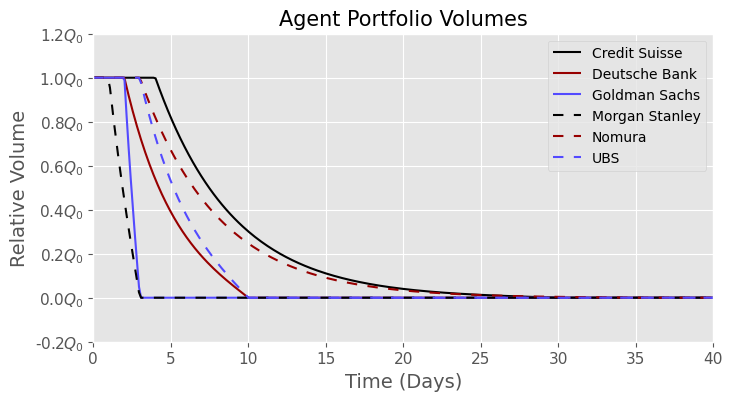

In [89]:
# Trading Strategies

plot_thesis_setup(alternative_colours = False)

for agent in agents:
    plt.plot(times, agent.trading_processes["BIDU"].volume_vector(times)/volumes_dict[agent.name][0], label = agent.name)

plt.xlim(start,end)
y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [str(np.round(tick,1)) + "$Q_0$" for tick in y_ticks])

plot_thesis_format(title = "Agent Portfolio Volumes", xlabel = "Time (Days)", ylabel = "Relative Volume", filename = "AgentTradingStrategies", save = True)
plt.show()

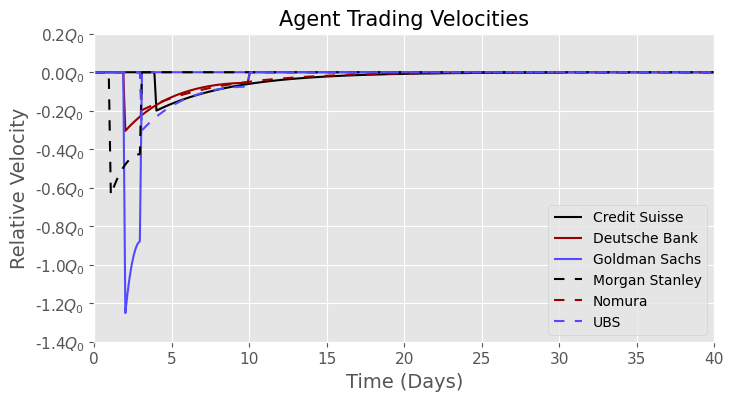

In [90]:
# Trading Velocities

plot_thesis_setup(alternative_colours = False)

for agent in agents:
    plt.plot(times, agent.trading_processes["BIDU"].velocity_vector(times)/volumes_dict[agent.name][0], label = agent.name)

plt.xlim(start, end)
y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [str(np.round(tick,1)) + "$Q_0$" for tick in y_ticks])

plot_thesis_format(title = "Agent Trading Velocities", xlabel = "Time (Days)", ylabel = "Relative Velocity", filename = "AgentTradingVelocities", save = True)
plt.show()

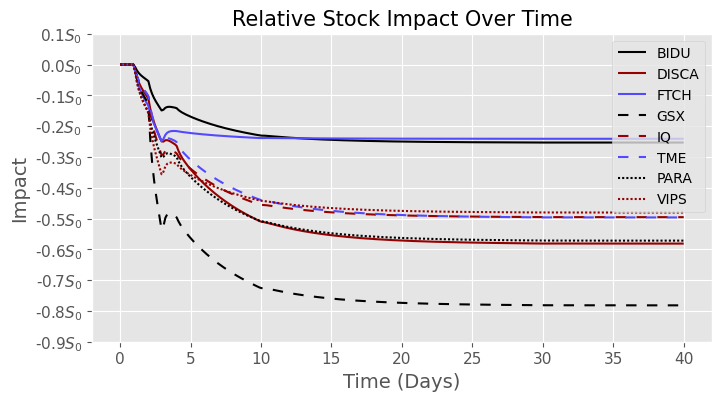

In [91]:
# Stock Impact

plot_thesis_setup(alternative_colours = False, colour_choice = 1)

for name in stock_names:
    stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    plt.plot(stock_processes.times, stock_processes.compute_impact()/stock_value_dict[name], label = stock_processes.stock_name)

y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [str(np.round(tick,1)) + r"$S_0$" for tick in y_ticks], fontsize = 11)
plt.xticks(fontsize = 11)



plot_thesis_format(title = "Relative Stock Impact Over Time", xlabel = "Time (Days)", ylabel = "Impact", filename = "LinearSimulationNoRandomImpacts", save = True)
plt.legend(loc = 'upper right')
plt.show()

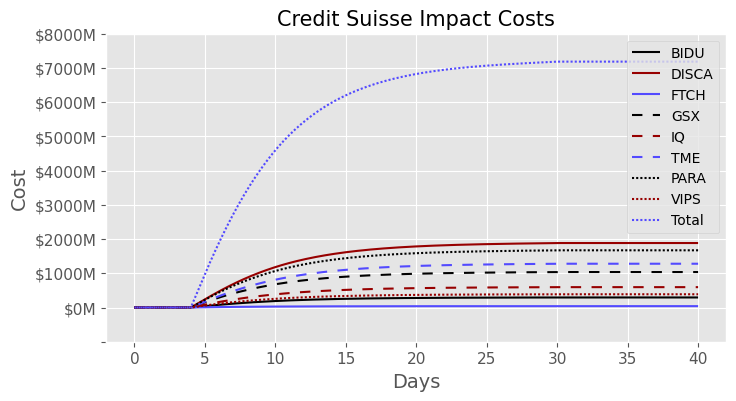

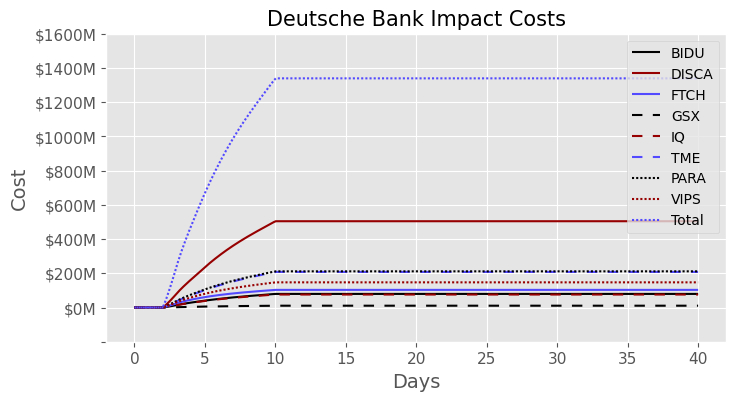

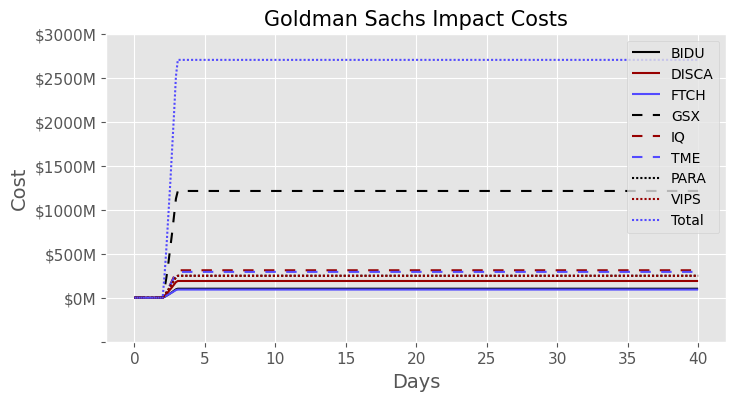

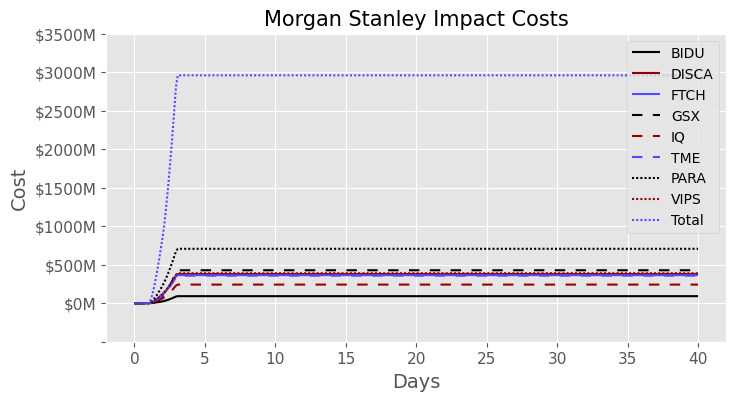

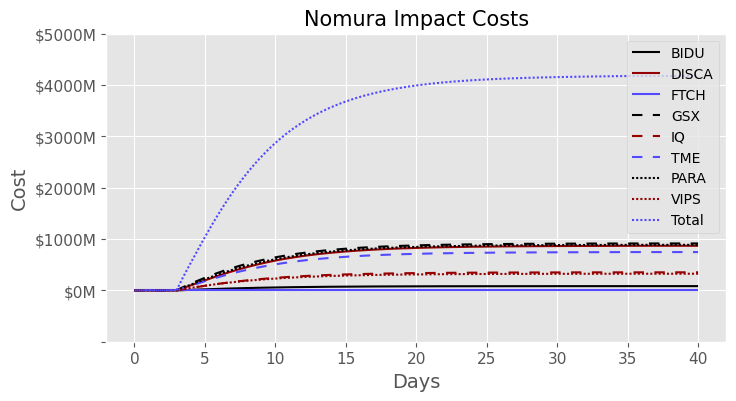

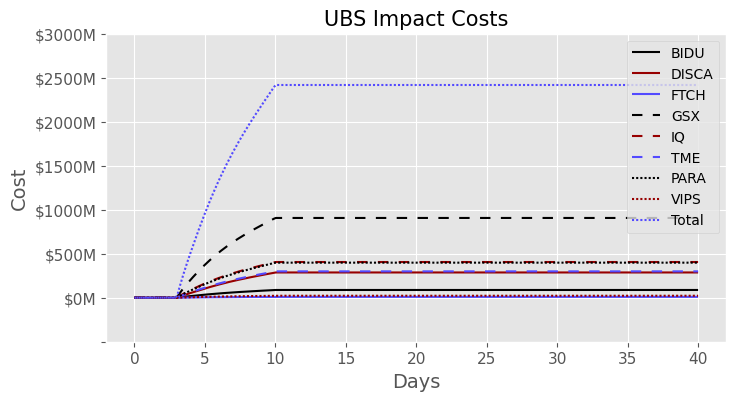

{'Credit Suisse': np.float64(7184.630672614465), 'Deutsche Bank': np.float64(1339.1939651300418), 'Goldman Sachs': np.float64(2702.799704012315), 'Morgan Stanley': np.float64(2959.5112323436547), 'Nomura': np.float64(4176.873316776623), 'UBS': np.float64(2417.36002581824)}


In [92]:
cost_dict = {}

for agent in agent_names:
    total = 0
    plot_thesis_setup(alternative_colours=False)
    for name in stock_names:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_impact_costs()[agent]
        total += costs
        plt.plot(stock_processes.times, costs, label = stock_processes.stock_name)
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = "Total")

    y_ticks = plt.yticks()[0]
    plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)

    
    plot_thesis_format(title = agent + " Impact Costs", xlabel = "Days", ylabel = "Cost", filename = agent + " DemonstratorModelImpactCosts", save = True)
    plt.legend(loc = 'upper right')
    plt.show()

print(cost_dict)

    

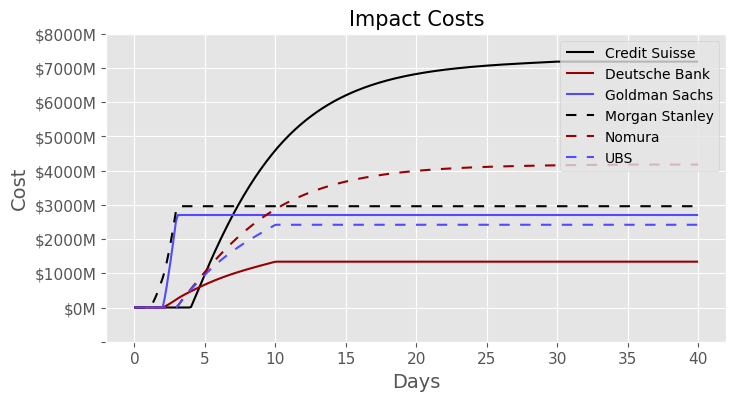

In [93]:
# Total costs only:

cost_dict = {}
plot_thesis_setup(alternative_colours=False)
for agent in agent_names:
    total = 0
    
    for name in stock_names:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_impact_costs()[agent]
        total += costs
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = agent)

y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)

    
plot_thesis_format(title = "Impact Costs", xlabel = "Days", ylabel = "Cost", filename = "Total DemonstratorModelImpactCosts", save = True)
plt.legend(loc = 'upper right')
plt.show()

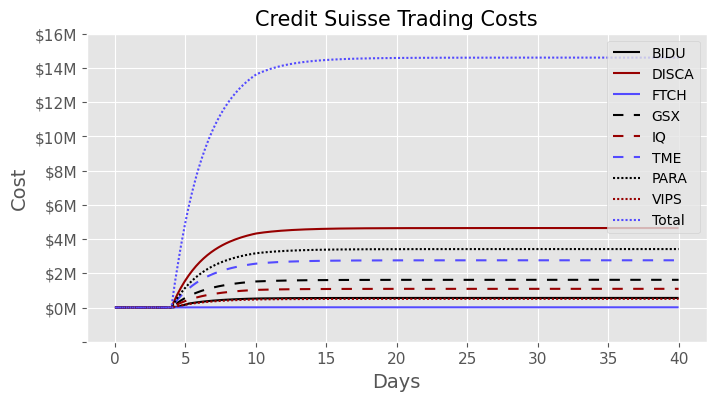

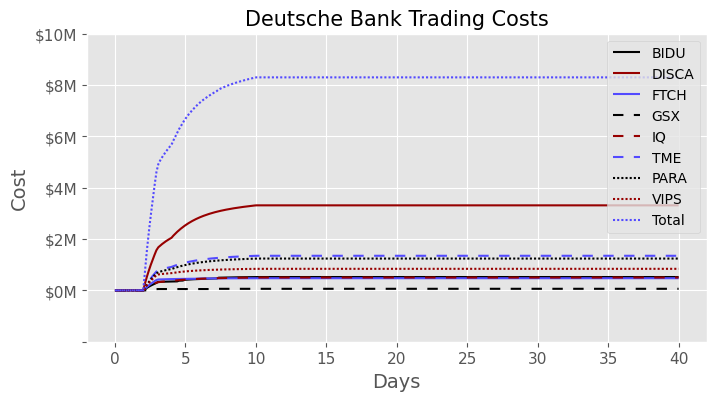

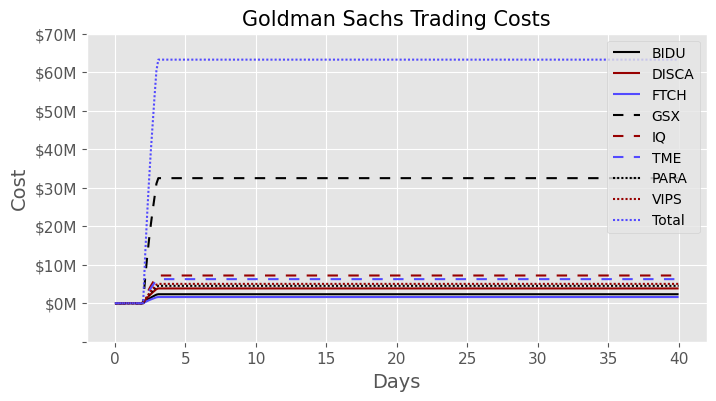

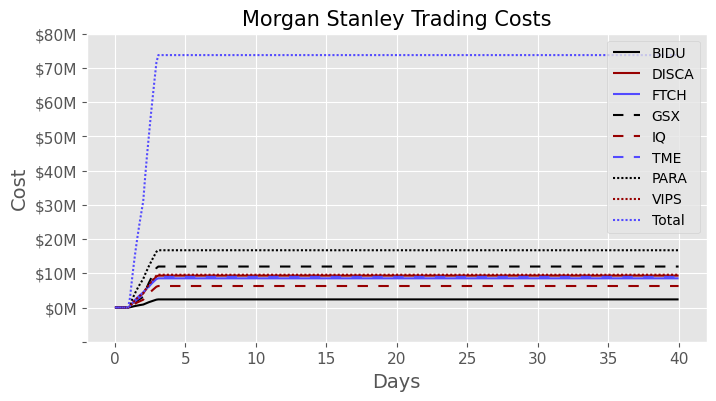

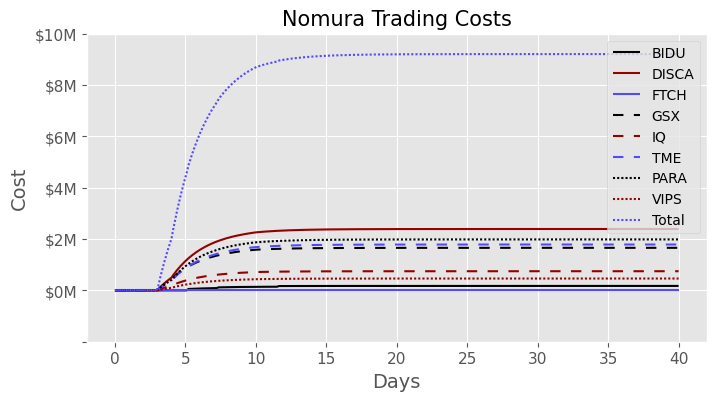

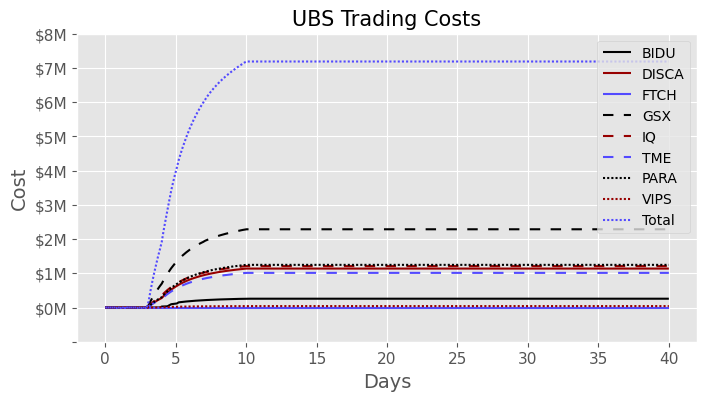

In [94]:
# Trading Costs

cost_dict = {}

for agent in agent_names:
    total = 0
    plot_thesis_setup(alternative_colours=False)
    for name in stock_names:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_trading_costs()[agent]
        total += costs
        plt.plot(stock_processes.times, costs, label = stock_processes.stock_name)
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = "Total")

    y_ticks = plt.yticks()[0]
    plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)

    
    plot_thesis_format(title = agent + " Trading Costs", xlabel = "Days", ylabel = "Cost", filename = agent + " DemonstratorModelTradingCosts", save = True)
    plt.legend(loc = 'upper right')
    plt.show()

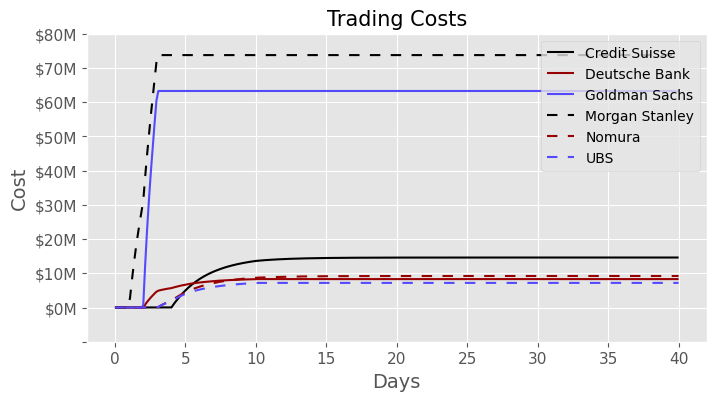

In [95]:
# Total Trading costs only:

cost_dict = {}
plot_thesis_setup(alternative_colours=False)
for agent in agent_names:
    total = 0
    
    for name in stock_names:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_trading_costs()[agent]
        total += costs
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = agent)

y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)

    
plot_thesis_format(title = "Trading Costs", xlabel = "Days", ylabel = "Cost", filename = "Total DemonstratorModelTradingCosts", save = True)
plt.legend(loc = 'upper right')
plt.show()

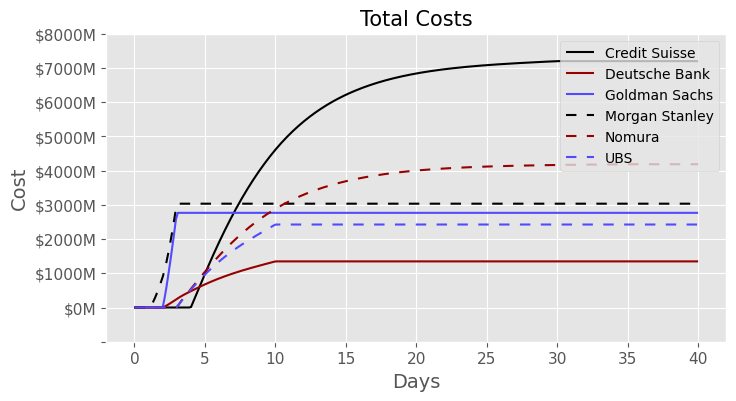

In [96]:
# Overall costs:

# Total Trading costs only:

cost_dict = {}
plot_thesis_setup(alternative_colours=False)
for agent in agent_names:
    total = 0
    
    for name in stock_names:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_trading_costs()[agent] + stock_processes.compute_impact_costs()[agent]
        total += costs
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = agent)

y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)

    
plot_thesis_format(title = "Total Costs", xlabel = "Days", ylabel = "Cost", filename = "Total DemonstratorModelCosts", save = True)
plt.legend(loc = 'upper right')
plt.show()

In [97]:
import UnpeturbedStockPathGeneration

correlations = pd.read_pickle("correlations_2.pkl")
vols = pd.read_pickle("vols.pkl")
means = pd.read_pickle("means.pkl")

means= pd.DataFrame(np.zeros(means.values.shape), means.index)

print(correlations)
print(vols)
print(means)




from scipy.linalg import cholesky
cholesky_root = cholesky(correlations)

print(cholesky_root)

           BIDU       TME      VIPS      FTCH        IQ      PARA     DISCA  \
BIDU   1.000000  0.283991  0.218040  0.287584  0.059336 -0.181438 -0.135466   
TME    0.283991  1.000000  0.221833  0.158957  0.172942 -0.132477 -0.155808   
VIPS   0.218040  0.221833  1.000000  0.158829  0.075004 -0.138310 -0.092714   
FTCH   0.287584  0.158957  0.158829  1.000000  0.005999 -0.205441 -0.153483   
IQ     0.059336  0.172942  0.075004  0.005999  1.000000 -0.091069 -0.031438   
PARA  -0.181438 -0.132477 -0.138310 -0.205441 -0.091069  1.000000  0.765854   
DISCA -0.135466 -0.155808 -0.092714 -0.153483 -0.031438  0.765854  1.000000   
GSX    0.025006  0.038138 -0.087145 -0.103319  0.012527  0.127439  0.130274   
NDX    0.451625  0.252712  0.224528  0.448662  0.071822 -0.077353 -0.094500   
S&P    0.367217  0.185294  0.160272  0.411753  0.069965  0.123069  0.171286   

            GSX       NDX       S&P  
BIDU   0.025006  0.451625  0.367217  
TME    0.038138  0.252712  0.185294  
VIPS  -0.087145 

BIDU266.13266.13
TME30.8730.87
VIPS45.2545.25
FTCH62.062.0
IQ28.0428.04
PARA100.34100.34
DISCA74.6574.65
GSX83.7983.79


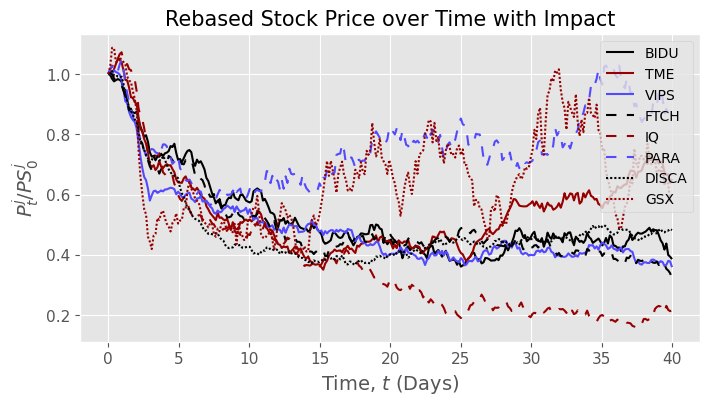

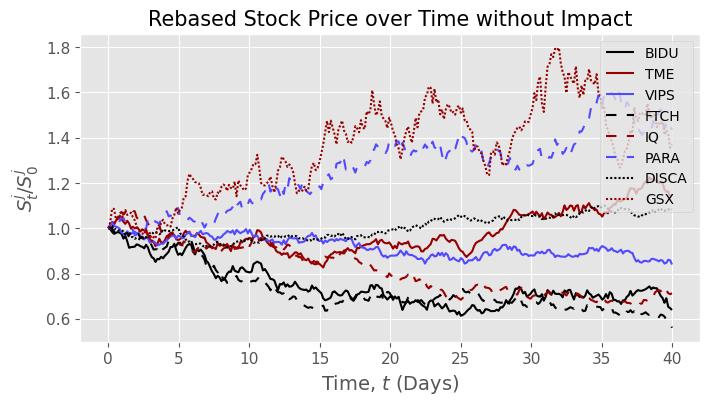

In [98]:
np.random.seed(seed = 13)

all_stock_and_index_values = np.array([266.13, 30.87, 45.25, 62, 28.04, 100.34, 74.65, 83.79, 13086.51, 3940.59])

stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(1, steps, cholesky_root, end/260, means, vols, all_stock_and_index_values)

excel_stock_name_order = ["BIDU", "TME", "VIPS", "FTCH", "IQ", "PARA", "DISCA", "GSX"]

i = 0
plot_thesis_setup()
for name in excel_stock_name_order:
    stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    stock_impact = stock_processes.compute_impact()
    stock_series = stock_time_series[0, :, i]
    print(name + str(stock_series[0]) + str(all_stock_and_index_values[i]))
    i += 1
    

    plt.plot(stock_processes.times, (stock_impact + stock_series)/stock_series[0], label = stock_processes.stock_name)

plot_thesis_format("Rebased Stock Price over Time with Impact", "Time, $t$ (Days)", "$P^j_t /PS^j_0$", filename= "Relative Stock Price over Time with Impact", save = True)
plt.legend(loc = "upper right")
plt.show()


plot_thesis_setup()
i = 0
for name in excel_stock_name_order:
    stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    stock_impact = stock_processes.compute_impact()
    stock_series = stock_time_series[0, :, i]
    i += 1

    plt.plot(stock_processes.times, stock_series/stock_series[0], label = stock_processes.stock_name)
plot_thesis_format("Rebased Stock Price over Time without Impact", "Time, $t$ (Days)", "$S^j_t / S^j_0$", filename= "Relative Stock Price over Time without Impact", save = True)
plt.legend(loc = "upper right")
plt.show()

BIDU266.13266.13
TME30.8730.87
VIPS45.2545.25
FTCH62.062.0
IQ28.0428.04
PARA100.34100.34
DISCA74.6574.65
GSX83.7983.79


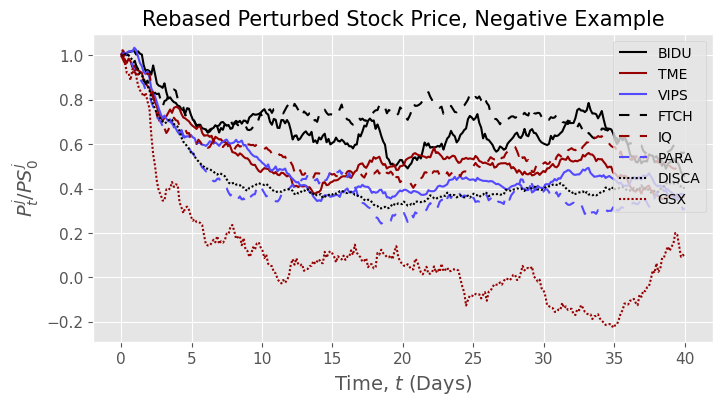

In [99]:
np.random.seed(seed = 69)

all_stock_and_index_values = np.array([266.13, 30.87, 45.25, 62, 28.04, 100.34, 74.65, 83.79, 13086.51, 3940.59])

stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(1, steps, cholesky_root, end/260, means, vols, all_stock_and_index_values)

excel_stock_name_order = ["BIDU", "TME", "VIPS", "FTCH", "IQ", "PARA", "DISCA", "GSX"]

i = 0
plot_thesis_setup()
for name in excel_stock_name_order:
    stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    stock_impact = stock_processes.compute_impact()
    stock_series = stock_time_series[0, :, i]
    print(name + str(stock_series[0]) + str(all_stock_and_index_values[i]))
    i += 1
    

    plt.plot(stock_processes.times, (stock_impact + stock_series)/stock_series[0], label = stock_processes.stock_name)

plot_thesis_format("Rebased Perturbed Stock Price, Negative Example", "Time, $t$ (Days)", "$P^j_t /PS^j_0$", filename= "RebasedNegativeExample", save = True)
plt.legend(loc = "upper right")
plt.show()

In [100]:
# We define a bespoke function to compute costs... since we want to be memory efficient
# So I'm not going to include this in one of the classes
tick_size  = (end - start) / steps
def compute_cash_process(stock_series, velocity, tick_size):

        cash_process = np.hstack((np.zeros(shape = (stock_series.shape[0], 1)), (-np.cumsum(velocity * stock_series, axis = 1) * tick_size)[:, :-1]))# Might have to make this an einsum

        return cash_process

In [101]:
stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(1000, steps, cholesky_root, end/260, means, vols, all_stock_and_index_values)

for agent in agents:
    i = 0

    cash = 0
    impact_and_trading_costs = 0

    for name in excel_stock_name_order:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        stock_impact_costs = stock_processes.compute_impact_costs()
        stock_trading_costs = stock_processes.compute_trading_costs()
        stock_series = stock_time_series[:, :, i]
        i += 1

        velocity = agent.trading_processes[name].velocity

        
        cash += compute_cash_process(stock_series, velocity, tick_size)

        impact_and_trading_costs += stock_impact_costs[agent.name] + stock_trading_costs[agent.name]

    # print(impact_and_trading_costs)

    # print(agent.name)
    average_cash = cash.mean(axis = 0)
    # plt.plot(times, average_cash)
    # plt.plot(times, average_cash - impact_and_trading_costs)
    # plt.plot(times, average_cash - impact_and_trading_costs + margins_dict[agent.name] - portfolio_value_dict[agent.name])
    # plt.show()




C:\Users\rapto\AppData\Local\Temp\ipykernel_10580\405660386.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels)


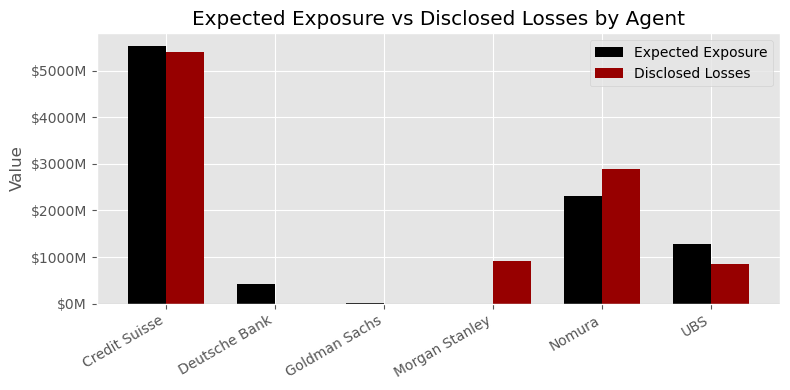

[np.float64(5522.828401507279), np.float64(418.707703249927), np.float64(7.2671249561174225), np.float64(0.8221557258093198), np.float64(2319.8741020628763), np.float64(1281.493174467071)]


In [102]:
stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(1000, steps, cholesky_root, end/260, means, vols, all_stock_and_index_values)

simulated_agent_names = []
simulated_expected_losses = []
simulated_liquidation_proceeds = []

for agent in agents:
    i = 0

    cash = 0
    impact_and_trading_costs = 0

    for name in excel_stock_name_order:
        stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        stock_impact_costs = stock_processes.compute_impact_costs()
        stock_trading_costs = stock_processes.compute_trading_costs()
        stock_series = stock_time_series[:, :, i]
        i += 1

        velocity = agent.trading_processes[name].velocity

        
        cash += compute_cash_process(stock_series, velocity, tick_size)

        impact_and_trading_costs += stock_impact_costs[agent.name] + stock_trading_costs[agent.name]

    simulated_agent_names.append(agent.name)
    simulated_liquidation_proceeds.append((cash[:, -1].mean() - impact_and_trading_costs[-1]))
    simulated_expected_losses.append(-(np.minimum(cash[:, -1] - impact_and_trading_costs[-1] + margins_dict[agent.name] - portfolio_value_dict[agent.name],0).mean()))

if simulated_model:
    disclosed_losses = [5400, 0, 0, 911, 2900, 861]
else:
    disclosed_losses = [5400, 10462-5400]


# --- Positioning warriors side by side (rectangles for each clan) ---
x = np.arange(len(simulated_agent_names))  # positions for each agent
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8, 4))

bars1 = ax.bar(x - width/2, simulated_expected_losses, width, label="Expected Exposure")
bars2 = ax.bar(x + width/2, disclosed_losses, width, label="Disclosed Losses")

# --- Adding titles and decoration (旗印, clan banners) ---
ax.set_ylabel("Value")
ax.set_title("Expected Exposure vs Disclosed Losses by Agent")
ax.set_xticks(x)
ax.set_xticklabels(simulated_agent_names, rotation=30, ha="right")
y = ax.get_yticks()
y_labels = ["$" + str(int(tick)) + "M" for tick in y]
ax.set_yticklabels(y_labels)

ax.legend()

# Draw a line of honor (zero line)
ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("Figures/LossesByAgent.pdf")
plt.show()

print(simulated_expected_losses)